In [2]:
%matplotlib inline

In [3]:
import os
import json
import time
import warnings
warnings.filterwarnings("ignore")

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
    make_scorer
)
from sklearn.model_selection import KFold

In [6]:
from xgboost import XGBRegressor
from skopt import BayesSearchCV
from skopt.space import Real, Integer

In [7]:
RANDOM_STATE = 42
USE_GPU = True
N_COMPONENTS = 20  # fixed, from prior PCA-dimensionality ablation

In [8]:
# ---- 0. Paths ----
DATA_DIR = r"E:\NSU\cse445\EDA attempt3\Dataset\ML dataset"
TRAIN_FILE = f"{DATA_DIR}/ML_train.csv"
TEST_FILE = f"{DATA_DIR}/ML_test.csv"

In [9]:
EMBED_DIR = r"E:\NSU\cse445\EDA attempt3\Bert ablation\Serialization ablation\bert serialisation embeddings"
SERIALIZATION_FILES = {
    "V1_baseline":   r"E:\NSU\cse445\EDA attempt3\NLP models\embeddings\bert_embeddings.csv",
    "V2_reordered":  f"{EMBED_DIR}/bert_V2_reordered_embeddings.csv",
    "V3_minimal":    f"{EMBED_DIR}/bert_V3_minimal_embeddings.csv",
    "V4_enriched":   f"{EMBED_DIR}/bert_V4_enriched_embeddings.csv",
}

In [10]:
train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)

In [11]:
TARGET_RAW = "target_usd"
TARGET_LOG = "log_target"
DROP_FROM_X = ["id", "target_usd", "log_target", "goal_usd"]

In [12]:
train_ids = set(train_df["id"])

In [13]:
# ---- 1. Evaluation helper ----
def evaluate_model(y_true_log, pred_log, actual_usd):
    pred_usd = np.expm1(pred_log)
    pred_usd = np.clip(pred_usd, a_min=0, a_max=None)

    mae_log = mean_absolute_error(y_true_log, pred_log)
    mse_log = mean_squared_error(y_true_log, pred_log)
    rmse_log = np.sqrt(mse_log)
    r2_log = r2_score(y_true_log, pred_log)

    mae_usd = mean_absolute_error(actual_usd, pred_usd)
    mse_usd = mean_squared_error(actual_usd, pred_usd)
    rmse_usd = np.sqrt(mse_usd)
    r2_usd = r2_score(actual_usd, pred_usd)

    rmsle = np.sqrt(mean_squared_log_error(actual_usd, pred_usd))

    return {
        "MAE_log": mae_log, "MSE_log": mse_log, "RMSE_log": rmse_log, "R2_log": r2_log,
        "MAE_USD": mae_usd, "MSE_USD": mse_usd, "RMSE_USD": rmse_usd, "R2_USD": r2_usd,
        "RMSLE": rmsle
    }

In [14]:
# ---- 2. BayesSearchCV setup (fixed across all variants) ----
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [15]:
rmse_scorer = make_scorer(rmse, greater_is_better=False)
CV = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
N_ITER_BAYES = 4

In [16]:
xgb_bayes_space = {
    "n_estimators":     Integer(200, 500),
    "learning_rate":    Real(0.01, 0.1, prior="log-uniform"),
    "max_depth":        Integer(4, 9),
    "min_child_weight": Integer(1, 7),
    "subsample":        Real(0.7, 1.0),
    "colsample_bytree": Real(0.7, 1.0),
    "reg_alpha":        Real(1e-3, 0.5, prior="log-uniform"),
    "reg_lambda":       Real(0.5, 3.0),
}

In [17]:
def make_search():
    base_estimator = XGBRegressor(
        objective="reg:squarederror", eval_metric="rmse",
        tree_method="hist", device="cuda" if USE_GPU else "cpu",
        random_state=RANDOM_STATE,
    )
    return BayesSearchCV(
        estimator=base_estimator, search_spaces=xgb_bayes_space, n_iter=N_ITER_BAYES,
        scoring=rmse_scorer, cv=CV, n_jobs=1,
        random_state=RANDOM_STATE, verbose=0, refit=True,
    )

In [18]:
# ---- 3. Ablation loop over serialization variants ----
ablation_results = []
best_params_by_variant = {}

In [19]:
for variant_name, path in SERIALIZATION_FILES.items():
    print(f"\n{'='*70}")
    print(f"SERIALIZATION VARIANT = {variant_name}")
    print(f"{'='*70}")

    variant_raw = pd.read_csv(path)
    feature_cols = [c for c in variant_raw.columns if c != "id"]
    train_mask = variant_raw["id"].isin(train_ids)

    pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
    pca.fit(variant_raw.loc[train_mask, feature_cols])
    reduced_all = pca.transform(variant_raw[feature_cols])

    reduced_cols = [f"bert_pca_{i}" for i in range(N_COMPONENTS)]
    reduced_df = pd.DataFrame(reduced_all, columns=reduced_cols)
    reduced_df.insert(0, "id", variant_raw["id"].values)

    explained = pca.explained_variance_ratio_.sum()
    print(f"Explained variance ({variant_name}): {explained:.3f}")

    merged_train = train_df.merge(reduced_df, on="id", how="left")
    merged_test = test_df.merge(reduced_df, on="id", how="left")

    assert merged_train.shape[0] == train_df.shape[0]
    assert merged_test.shape[0] == test_df.shape[0]
    assert merged_train[reduced_cols].isna().sum().sum() == 0
    assert merged_test[reduced_cols].isna().sum().sum() == 0

    X_train = merged_train.drop(columns=DROP_FROM_X, errors="ignore")
    X_test = merged_test.drop(columns=DROP_FROM_X, errors="ignore")
    y_train = merged_train[TARGET_LOG].copy()
    y_test = merged_test[TARGET_LOG].copy()
    actual_usd = merged_test[TARGET_RAW].to_numpy()

    assert list(X_train.columns) == list(X_test.columns)

    search = make_search()
    start_time = time.time()
    search.fit(X_train, y_train)
    tuning_time = time.time() - start_time

    best_model = search.best_estimator_
    pred_log = best_model.predict(X_test)

    metrics = evaluate_model(y_test, pred_log, actual_usd)
    metrics["Serialization"] = variant_name
    metrics["Explained_Variance"] = explained
    metrics["Best_CV_RMSE_log"] = -search.best_score_
    metrics["Tuning_Time_Seconds"] = tuning_time

    ablation_results.append(metrics)
    best_params_by_variant[variant_name] = dict(search.best_params_)

    print(f"RMSLE={metrics['RMSLE']:.4f} | R2_log={metrics['R2_log']:.4f} | "
          f"R2_USD={metrics['R2_USD']:.4f} | time={tuning_time:.1f}s")


SERIALIZATION VARIANT = V1_baseline
Explained variance (V1_baseline): 0.727
RMSLE=1.5065 | R2_log=0.7578 | R2_USD=0.1769 | time=61.4s

SERIALIZATION VARIANT = V2_reordered
Explained variance (V2_reordered): 0.738
RMSLE=1.2910 | R2_log=0.8221 | R2_USD=0.2387 | time=37.2s

SERIALIZATION VARIANT = V3_minimal
Explained variance (V3_minimal): 0.788
RMSLE=2.2552 | R2_log=0.4586 | R2_USD=0.0435 | time=33.8s

SERIALIZATION VARIANT = V4_enriched
Explained variance (V4_enriched): 0.735
RMSLE=1.3740 | R2_log=0.7984 | R2_USD=0.1573 | time=39.7s


In [20]:
# ---- 4. Results table ----
results_df = pd.DataFrame(ablation_results)
results_df = results_df[[
    "Serialization", "Explained_Variance",
    "MAE_log", "MSE_log", "RMSE_log", "R2_log",
    "MAE_USD", "MSE_USD", "RMSE_USD", "R2_USD",
    "RMSLE", "Best_CV_RMSE_log", "Tuning_Time_Seconds"
]]
print("\n" + "="*70)
print("ABLATION RESULTS: Serialization template variants")
print("="*70)
print(results_df)


ABLATION RESULTS: Serialization template variants
  Serialization  Explained_Variance   MAE_log   MSE_log  RMSE_log    R2_log  \
0   V1_baseline            0.726705  1.115845  2.275488  1.508472  0.757791   
1  V2_reordered            0.737879  0.958204  1.671239  1.292764  0.822109   
2    V3_minimal            0.787575  1.668278  5.086143  2.255248  0.458618   
3   V4_enriched            0.734810  1.031318  1.893692  1.376115  0.798431   

        MAE_USD       MSE_USD       RMSE_USD    R2_USD     RMSLE  \
0  14587.044370  9.713670e+09   98557.950385  0.176912  1.506474   
1  13633.383311  8.984408e+09   94786.117499  0.238706  1.290980   
2  16376.884365  1.128845e+10  106247.138713  0.043472  2.255248   
3  14480.790862  9.945472e+09   99726.987097  0.157270  1.374035   

   Best_CV_RMSE_log  Tuning_Time_Seconds  
0          1.535839            61.355554  
1          1.320913            37.210756  
2          2.268563            33.765811  
3          1.403544            39.702516

In [21]:
results_df.to_csv("serialization_ablation_results.csv", index=False)
with open("serialization_ablation_best_params.json", "w") as f:
    json.dump(best_params_by_variant, f, indent=2, default=str)

In [22]:
print("\nSaved: serialization_ablation_results.csv")
print("Saved: serialization_ablation_best_params.json")


Saved: serialization_ablation_results.csv
Saved: serialization_ablation_best_params.json


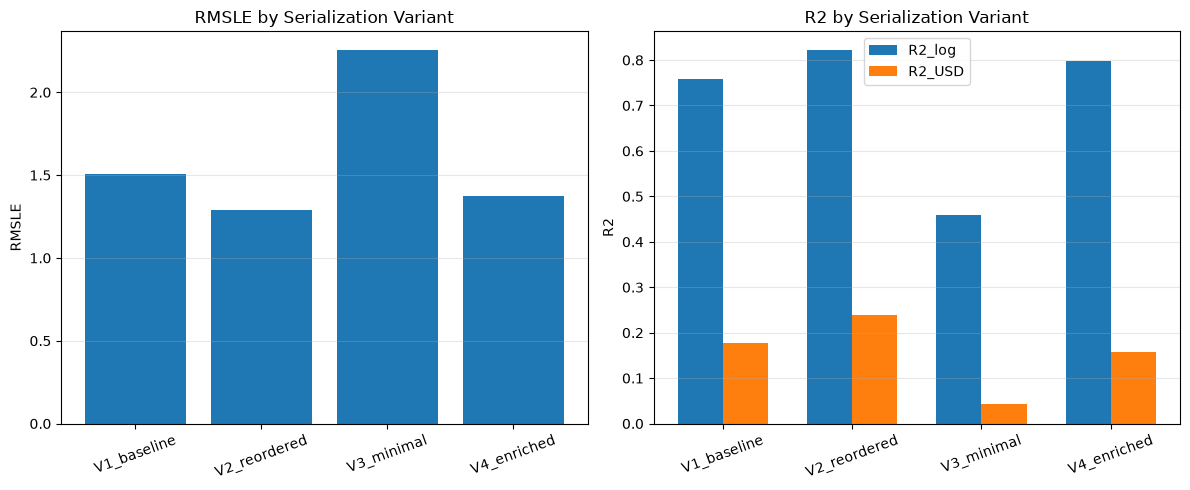

Saved: serialization_ablation_plot.png


In [23]:
# ---- 5. Plot ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(results_df["Serialization"], results_df["RMSLE"])
axes[0].set_ylabel("RMSLE")
axes[0].set_title("RMSLE by Serialization Variant")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(True, alpha=0.3, axis="y")
x = np.arange(len(results_df))
width = 0.35
axes[1].bar(x - width/2, results_df["R2_log"], width, label="R2_log")
axes[1].bar(x + width/2, results_df["R2_USD"], width, label="R2_USD")
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df["Serialization"], rotation=20)
axes[1].set_ylabel("R2")
axes[1].set_title("R2 by Serialization Variant")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("serialization_ablation_plot.png", dpi=150)
plt.show()
print("Saved: serialization_ablation_plot.png")